# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [1093]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
import multiprocessing
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import DirectedGraph, UndirectedGraph
from NEMtropy import matrix_generator as mg
from NEMtropy.network_functions import build_adjacency_from_edgelist
from scipy.stats import spearmanr


In [1094]:
SEED = 42

In [1095]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_GREEN = 'palegreen'
COLOR_RED = 'lightcoral'
COLOR_YELLOW = 'gold'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [1096]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
### OUTPUT_PATH_ERGMS = os.path.join(OUTPUT_PATH, "ERGMs")


# Recreate the subdirectories
### os.makedirs(OUTPUT_PATH_ERGMS)

In [1097]:
# Define the directory containing the .gml files
directory = 'datasets'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files: 100%|██████████| 4/4 [00:00<00:00, 27.19it/s]

Finished loading graph_jazz_collab
Finished loading graph1.2
Finished loading graph1.1
Finished loading graph_madrid


# 2. Centralities and influence

## 1. Task: Write a function to simulate the SIR dynamic on a generic network and provide visualisation.
The function should take in input:
- a network, e.g. if you are using networkx a generic nx.Graph,
- the infection rate β,
- the recovery rate β,
- an infected seed node.

For the visualisation, you have to plot each of the requested network, using a continous colormap to denote each node Qi A colorbar for interpretation should be provided.

Graphs to consider:
- A Barabasi-Albert network with N = 100 and m = 3.
- A 1D regular lattice with periodic condition, with N = 100 nodes and coordination number k = 6.

Hint: You have to map the Qi values to a continous colormap. The colorbar is needed to interpret the plot.
Hint: We defined the SIR Qi in class. In order to have a reliable result, for each node you need to average Qi over a large sample of simulations.

In [1100]:
def simulate_SIR(network, infection_rate, recovery_rate, infected_seed_node):
    """
    
    :param network: 
    :param infection_rate: 
    :param recovery_rate: 
    :param infected_seed_node: 
    :return: 
    """
    
    # General idea: use makers to denote status of "patients"

    # Initialize node statuses: 0 for susceptible, 1 for infected, 2 for recovered
    
    # SIR-model: S -> Infection => Infected -> Recovery => Recovered (immune)
    # susceptible state: describes those agents who are in a healthy state, but are prone to become ill
    # infected state: describes those agents who are under the effects of the disease
    # recovered state: describes those agents who got the disease and cannot transmit it because (e.g.) they recovered, or because they are dead
    
    # Infection rate Beta: probability to get infected
    # Recovery rate Gamma: probability to recover
    
    
    node_statuses = {node: 0 for node in network.nodes()} # Initiate node -> status dict
    node_statuses[infected_seed_node] = 1  # Set the seed node as infected

    susceptible_count = [len(network.nodes()) - 1]  # Initial count of susceptible nodes (excluding the seed)
    infected_count = [1]  # Initial count of infected nodes
    recovered_count = [0]  # Initial count of recovered nodes

    # Simulation loop
    while True:
        # Determine new infections
        new_infections = set()
        for node in network.nodes():
            # For perfromance reasons
            if node_statuses[node] == 1:  # If the node is infected
                neighbors = list(network.neighbors(node))
                
                # Check al neighbors if an infection happened
                for neighbor in neighbors:
                    if node_statuses[neighbor] == 0 and np.random.random() < infection_rate:
                        new_infections.add(neighbor)

        # Update statuses for new infections
        for node in new_infections:
            node_statuses[node] = 1

        # Determine recoveries
        recoveries = set()
        for node in network.nodes():
            if node_statuses[node] == 1:  # If the node is infected
                if np.random.random() < recovery_rate:
                    recoveries.add(node)

        # Update statuses for recoveries
        for node in recoveries:
            node_statuses[node] = 2

        # Count the number of nodes in each status
        susceptible_count.append(list(node_statuses.values()).count(0))
        infected_count.append(list(node_statuses.values()).count(1))
        recovered_count.append(list(node_statuses.values()).count(2))

        # Stop the simulation if no new infections or recoveries occur
        if len(new_infections) == 0 and len(recoveries) == 0:
            break


    # Mapping node statuses to a continuous colormap
    node_status_values = [node_statuses[node] for node in network.nodes()]
    norm = plt.Normalize(min(node_status_values), max(node_status_values))
    cmap = plt.cm.get_cmap('viridis')

    # Visualization with continuous colormap
    plt.figure(figsize=(10, 6))
    ax = plt.subplot(111)
    pos = nx.spring_layout(network)
    nx.draw(network, pos=pos, node_color=node_status_values,
            cmap=cmap, with_labels=True, node_size=300, vmin=min(node_status_values),
            vmax=max(node_status_values), edge_color='gray', width=0.5, ax=ax)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Node Status (0: Susceptible, 1: Infected, 2: Recovered)')
    plt.title('SIR Simulation on Network with Continuous Colormap')
    plt.show()

In [1101]:
# Generating Barabasi-Albert network
N_BA = 100  # Number of nodes
m = 3    # Number of edges to attach from a new node to existing nodes
barabasi_albert_graph = nx.barabasi_albert_graph(N_BA, m)

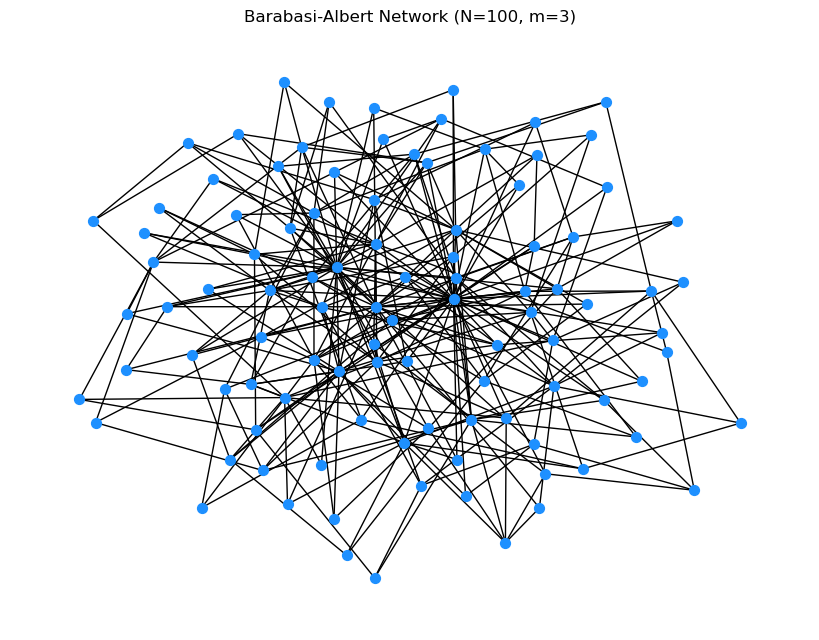

In [1102]:
# Visualizing Barabasi-Albert network
plt.figure(figsize=(8, 6))
nx.draw(barabasi_albert_graph, node_size=50, node_color=COLOR_BLUE, with_labels=False)
plt.title('Barabasi-Albert Network (N=100, m=3)')
plt.show()

In [1103]:
# Generating 1D regular lattice with periodic conditions
N_RL = 100  # Number of nodes
k = 6    # Number of nearest neighbors


lattice_graph = nx.Graph()

# Create nodes and periodic edges
for i in range(N_RL):
    lattice_graph.add_node(i)
    for j in range(1, k // 2 + 1):
        lattice_graph.add_edge(i, (i + j) % N_RL)  # Connect to k/2 nodes on each side
        lattice_graph.add_edge(i, (i - j) % N_RL)

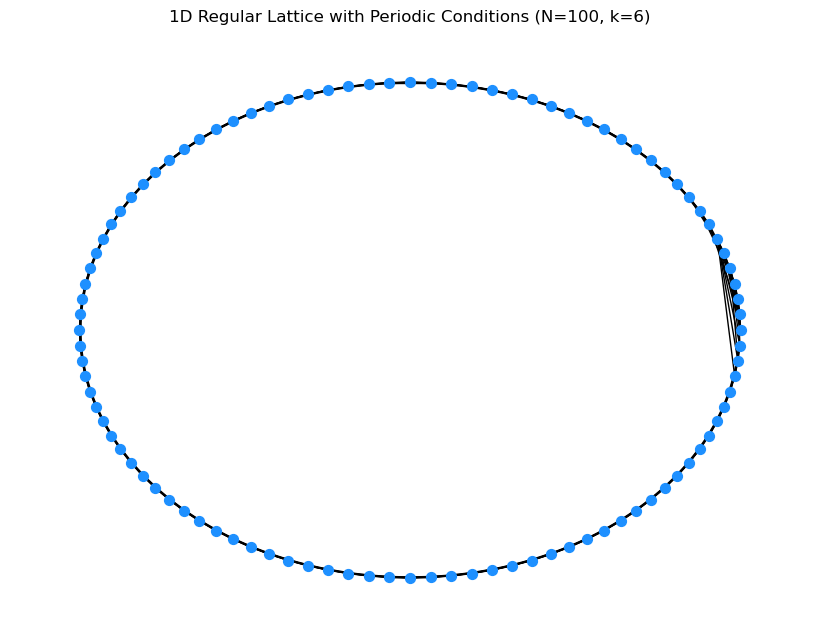

In [1104]:
# Visualizing 1D regular lattice
plt.figure(figsize=(8, 6))
nx.draw_circular(lattice_graph, node_size=50, node_color=COLOR_BLUE, with_labels=False)
plt.title('1D Regular Lattice with Periodic Conditions (N=100, k=6)')
plt.show()

In [1105]:
BETA = 0.2
GAMMA = 0.6

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_22388/607607875.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


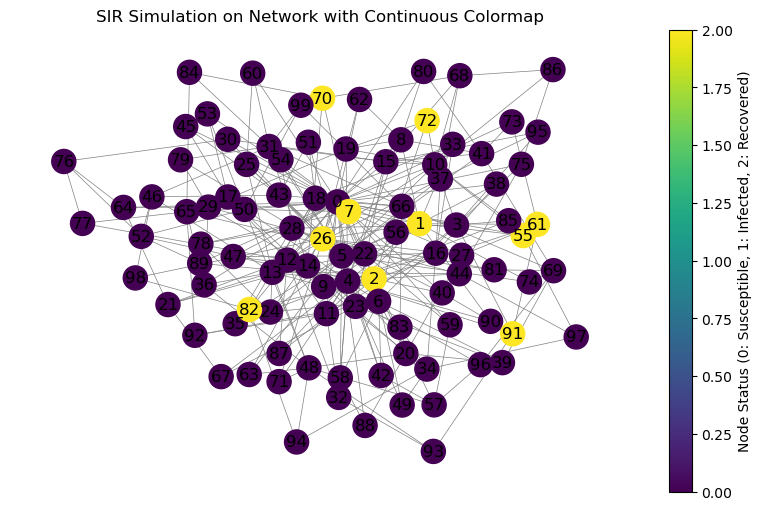

In [1106]:
simulate_SIR(network=barabasi_albert_graph, infection_rate=BETA, recovery_rate=GAMMA, infected_seed_node=1)

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_22388/607607875.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


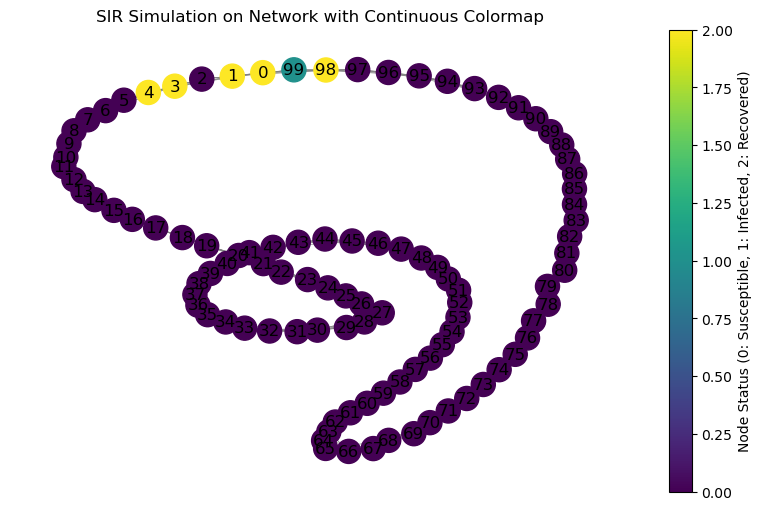

In [1107]:
simulate_SIR(network=lattice_graph, infection_rate=BETA, recovery_rate=GAMMA, infected_seed_node=1)

In [1108]:
def plot_network_state(network, node_statuses, pos, step, step_title):
    # Mapping node statuses to specific colors
    color_map = {0: COLOR_BLUE, 1: COLOR_RED, 2: COLOR_LIGHT_GRAY}

    # Get node colors based on their statuses
    node_colors = [color_map[node_statuses[node]] for node in network.nodes()]

    # Visualization with specific node colors
    plt.figure(figsize=(10, 6))
    ax = plt.subplot(111)
    #pos = nx.spring_layout(network)
    nx.draw(network, pos=pos, node_color=node_colors,
            with_labels=True, node_size=300, edge_color='gray', width=0.5, ax=ax)

    # Legend for the colors
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for status, color in color_map.items()]
    plt.legend(handles, ['Susceptible', 'Infected', 'Recovered'], loc='best')
    plt.title(f'SIR Simulation on Network with Specific Node Colors - {step_title} {step}')
    plt.show()

In [1109]:
SAMPLES = 5
SEED_NODE = 17
SEED_OFFSET = 42

In [1110]:
def simulate_SIR_scenario(network, infection_rate, recovery_rate, infected_seed_node, plot=False):
    """
    
    :param network: 
    :param infection_rate: 
    :param recovery_rate: 
    :param infected_seed_node: 
    :return: 
    """

    # General idea: use makers to denote status of "patients"

    # Initialize node statuses: 0 for susceptible, 1 for infected, 2 for recovered

    # SIR-model: S -> Infection => Infected -> Recovery => Recovered (immune)
    # susceptible state: describes those agents who are in a healthy state, but are prone to become ill
    # infected state: describes those agents who are under the effects of the disease
    # recovered state: describes those agents who got the disease and cannot transmit it because (e.g.) they recovered, or because they are dead

    # Infection rate Beta: probability to get infected
    # Recovery rate Gamma: probability to recover


    node_statuses = {node: 0 for node in network.nodes()} # Initiate node -> status dict
    node_statuses[infected_seed_node] = 1  # Set the seed node as infected

    susceptible_count = [len(network.nodes()) - 1]  # Initial count of susceptible nodes (excluding the seed)
    infected_count = [1]  # Initial count of infected nodes
    recovered_count = [0]  # Initial count of recovered nodes

    # Generate the initial layout of the network
    pos = nx.spring_layout(network)

    step = 0
    
    # Initialize simulation
    if plot:
        plot_network_state(network, node_statuses, pos, step, "Initial State")

    # Start simulation
    # Simulation loop
    while True:
        step += 1
        
        
        # INFECTIONS
        ###
        # Determine new infections
        new_infections = set()
        for node in network.nodes():
            # For perfromance reasons
            if node_statuses[node] == 1:  # If the node is infected
                neighbors = list(network.neighbors(node))

                # Check al neighbors if an infection happened
                for neighbor in neighbors:
                    if node_statuses[neighbor] == 0 and np.random.random() < infection_rate:
                        new_infections.add(neighbor)

        # Update statuses for new infections
        for node in new_infections:
            node_statuses[node] = 1
        ###


        # RECOVERIES
        ###
        # Determine recoveries
        recoveries = set()
        for node in network.nodes():
            if node_statuses[node] == 1:  # If the node is infected
                if np.random.random() < recovery_rate:
                    recoveries.add(node)

        # Update statuses for recoveries
        for node in recoveries:
            node_statuses[node] = 2
        ###

        # Count the number of nodes in each status
        susceptible_count.append(list(node_statuses.values()).count(0))
        infected_count.append(list(node_statuses.values()).count(1))
        recovered_count.append(list(node_statuses.values()).count(2))

        
        if plot:
            plot_network_state(network, node_statuses, pos, step, f"Step")
            
        # Stop the simulation if no new infections or recoveries occur
        if len(new_infections) == 0 and len(recoveries) == 0:
            break

    if plot:
        plot_network_state(network, node_statuses, pos, step, f"Final State")
        
        
    return {
        's_count': susceptible_count,
        'i_count': infected_count,
        'r_count': recovered_count,
        'nodes_statues': node_statuses
    }

In [1111]:
simulate_SIR_scenario(network=barabasi_albert_graph, infection_rate=BETA, recovery_rate=GAMMA, infected_seed_node=SEED_NODE, plot=False)

{'s_count': [99, 98, 98],
 'i_count': [1, 1, 1],
 'r_count': [0, 1, 1],
 'nodes_statues': {0: 0,
  1: 0,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 0,
  7: 0,
  8: 0,
  9: 0,
  10: 0,
  11: 0,
  12: 2,
  13: 0,
  14: 0,
  15: 0,
  16: 0,
  17: 1,
  18: 0,
  19: 0,
  20: 0,
  21: 0,
  22: 0,
  23: 0,
  24: 0,
  25: 0,
  26: 0,
  27: 0,
  28: 0,
  29: 0,
  30: 0,
  31: 0,
  32: 0,
  33: 0,
  34: 0,
  35: 0,
  36: 0,
  37: 0,
  38: 0,
  39: 0,
  40: 0,
  41: 0,
  42: 0,
  43: 0,
  44: 0,
  45: 0,
  46: 0,
  47: 0,
  48: 0,
  49: 0,
  50: 0,
  51: 0,
  52: 0,
  53: 0,
  54: 0,
  55: 0,
  56: 0,
  57: 0,
  58: 0,
  59: 0,
  60: 0,
  61: 0,
  62: 0,
  63: 0,
  64: 0,
  65: 0,
  66: 0,
  67: 0,
  68: 0,
  69: 0,
  70: 0,
  71: 0,
  72: 0,
  73: 0,
  74: 0,
  75: 0,
  76: 0,
  77: 0,
  78: 0,
  79: 0,
  80: 0,
  81: 0,
  82: 0,
  83: 0,
  84: 0,
  85: 0,
  86: 0,
  87: 0,
  88: 0,
  89: 0,
  90: 0,
  91: 0,
  92: 0,
  93: 0,
  94: 0,
  95: 0,
  96: 0,
  97: 0,
  98: 0,
  99: 0}}

In [1112]:
def iterate_nodes_with_offset(graph, offset):
    nodes = list(graph.nodes())

    if offset >= 0:
        offset = offset % len(nodes)
        nodes_to_iterate = nodes[offset:] + nodes[:offset]
    else:
        offset = abs(offset) % len(nodes)
        nodes_to_iterate = nodes[-offset:] + nodes[:-offset]

    return nodes_to_iterate

In [1113]:
def calculate_average(data):
    # Create a dictionary to store sums for each key
    sum_dict = {}

    # Loop through each dictionary in the data
    for d in data.values():
        for key, value in d.items():
            # Add the value to the sum for the corresponding key
            if key in sum_dict:
                sum_dict[key] += value
            else:
                sum_dict[key] = value

    # Calculate the average for each key
    num_dicts = len(data)
    avg_dict = {key: value / num_dicts for key, value in sum_dict.items()}

    return avg_dict

In [1114]:
def simulate_SIR(network=barabasi_albert_graph, infection_rate=0.1, recovery_rate=0.5, plot=False, sample_size=100, seed_start=1):

    rearranged_nodes = iterate_nodes_with_offset(network, seed_start)
    
    result = {}

    # for all different seeds:
    for node in rearranged_nodes:
        print(node)
        


        aggregated_values = {}
        results = []
    
        # simulate for each starting node sample_size times
        for iteration in range(0, sample_size+1, 1):
            pass

            simulation_run = simulate_SIR_scenario(network=barabasi_albert_graph, infection_rate=infection_rate, recovery_rate=recovery_rate, infected_seed_node=node, plot=plot)
            results.append(simulation_run["nodes_statues"])

        for node_status in results:
            for key, value in node_status.items():
                if key not in aggregated_values:
                    aggregated_values[key] = []
                aggregated_values[key].append(value)
        
        average_values = {key: sum(values) / len(values) for key, values in aggregated_values.items()}
        result[f"starting_node_{node}"]=average_values
        #print(average_values)
    
    print(result)
    # aggregate and average results
    node_values = calculate_average(result)
    
    return node_values

In [1115]:
node_values_ba = simulate_SIR(network=barabasi_albert_graph, infection_rate=BETA, recovery_rate=GAMMA, plot=False, sample_size=SAMPLES, seed_start=SEED_OFFSET)

42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
{'starting_node_42': {0: 0.0, 1: 0.0, 2: 0.3333333333333333, 3: 0.0, 4: 0.0, 5: 0.3333333333333333, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 0.0, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 0.0, 20: 0.0, 21: 0.0, 22: 0.0, 23: 0.0, 24: 0.0, 25: 0.0, 26: 0.0, 27: 0.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.0, 33: 0.0, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 0.0, 40: 0.0, 41: 0.0, 42: 1.3333333333333333, 43: 0.0, 44: 0.0, 45: 0.0, 46: 0.0, 47: 0.0, 48: 0.0, 49: 0.0, 50: 0.0, 51: 0.0, 52: 0.0, 53: 0.0, 54: 0.0, 55: 0.0, 56: 0.0, 57: 0.6666666666666666, 58: 0.0, 59: 0.0, 60: 0.0, 61: 0.0, 62: 0.0, 63: 0.0, 64: 0.0, 65: 0.0, 66: 0.0, 67: 0.0, 68: 0.0, 69: 0.0, 70: 0.0,

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_22388/1748532764.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


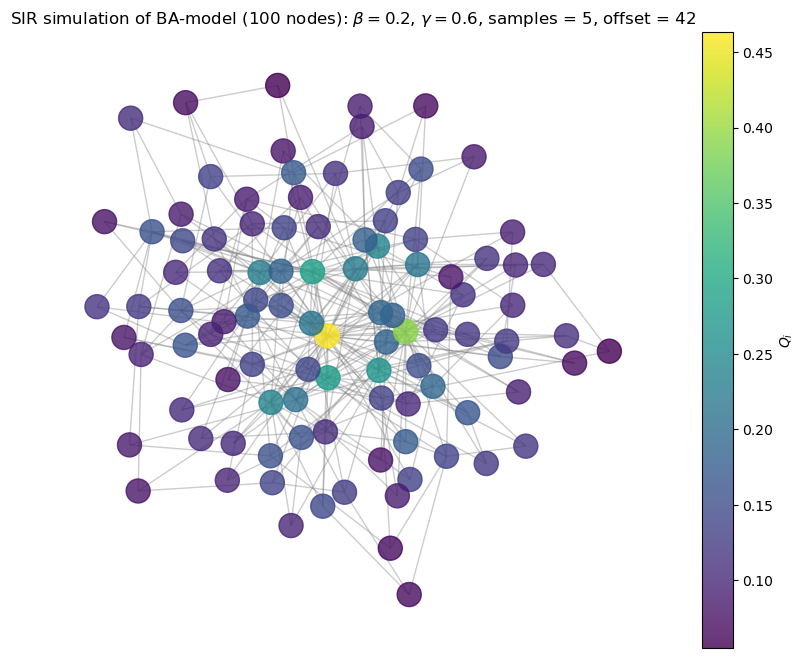

In [1116]:
 # Create a colormap
cmap = plt.cm.get_cmap('viridis')

node_values_ba = list(node_values_ba.values())
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(barabasi_albert_graph)
nodes = nx.draw_networkx_nodes(barabasi_albert_graph, pos=pos, node_color=node_values_ba, cmap=cmap, node_size=300, alpha=0.8)
edges = nx.draw_networkx_edges(barabasi_albert_graph, pos=pos, edge_color='gray', alpha=0.4)

cbar = plt.colorbar(nodes)
cbar.set_label(fr'$Q_{"i"}$')
plt.title(fr'SIR simulation of BA-model ({N_BA} nodes): $\beta = {BETA}$, $\gamma = {GAMMA}$, samples = {SAMPLES}, offset = {SEED_OFFSET}')
plt.axis('off')
plt.show()

In [1117]:
node_values_rl = simulate_SIR(network=lattice_graph, infection_rate=BETA, recovery_rate=GAMMA, plot=False,
                           sample_size=SAMPLES, seed_start=SEED_OFFSET)

39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
0
1
99
2
98
3
97
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
{'starting_node_39': {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.5, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 0.0, 15: 0.0, 16: 0.0, 17: 0.0, 18: 0.0, 19: 0.0, 20: 1.0, 21: 0.0, 22: 0.0, 23: 0.0, 24: 0.0, 25: 0.0, 26: 0.0, 27: 0.3333333333333333, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.0, 33: 0.0, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 1.8333333333333333, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: 0.0, 46: 0.0, 47: 0.0, 48: 0.0, 49: 0.0, 50: 0.0, 51: 0.0, 52: 0.0, 53: 0.0, 54: 0.0, 55: 0.0, 56: 0.0, 57: 0.0, 58: 0.0, 59: 0.0, 60: 0.0, 61: 0.0, 62: 0.0, 63: 0.0, 64: 0.0, 65: 0.0, 66: 0.0, 67: 0.0, 68: 0.0, 69: 0.6666666666666666, 70: 0.0, 71: 0.0, 72: 0

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_22388/275618727.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis')


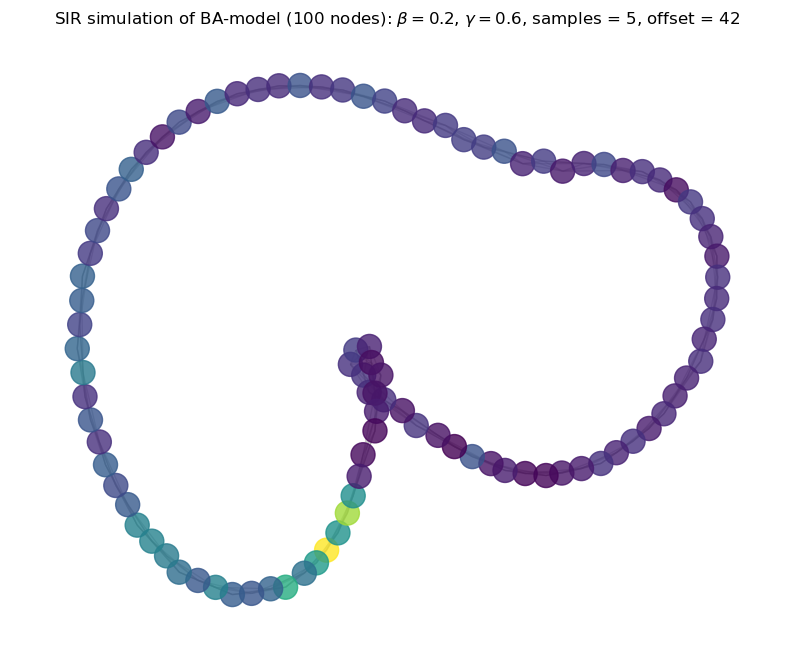

In [1118]:
# Create a colormap
cmap = plt.cm.get_cmap('viridis')

node_values_rl = list(node_values_rl.values())
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(lattice_graph)
noswa_rl = nx.draw_networkx_nodes(lattice_graph, pos=pos, node_color=node_values_rl, cmap=cmap, node_size=300,
                               alpha=0.8)
edges = nx.draw_networkx_edges(lattice_graph, pos=pos, edge_color='gray', alpha=0.4)

cbar = plt.colorbar(nodes)
cbar.set_label(fr'$Q_{"i"}$')
plt.title(
    fr'SIR simulation of BA-model ({N_RL} nodes): $\beta = {BETA}$, $\gamma = {GAMMA}$, samples = {SAMPLES}, offset = {SEED_OFFSET}')
plt.axis('off')
plt.show()

## 2. Evaluate the SIR spreading ability of the nodes vs their centrality.
For each of the required network use the SIR function you defined in the previous point to compute the correlation coefficient (Spearmann correlation) of the spreading ability Qi with the following centrality measures:  degree, closeness, PageRank and k-core centrality.
Plot the correlation coefficient as a function of λ= β/μ in the range[0.25,4]λ_C, where λ_C is the epidemic threshold, with step size 0.25.
Graphs to consider:
- Erdos-Renyi with N= 100 nodes and p= 6/N.
- Barabasi-Albert with N= 100nodes and m= 3
- Watts-Strogatz with N= 100 nodes, rewiring probability pr= 0.02and coordination number k= 6.

In [1119]:
N = 100
p = 6 / 100
m = 3
pr = 0.02
k = 6
network_er = nx.erdos_renyi_graph(N, p)
network_ba = nx.barabasi_albert_graph(N, m)
network_ws = nx.watts_strogatz_graph(N, k, pr)

In [1120]:
def calculate_centralities(graph):
    centralities = {
        "degree": nx.degree_centrality(graph),
        "closeness": nx.closeness_centrality(graph),
        "pagerank": nx.pagerank(graph),
        "kcore": nx.core_number(graph)
    }

    return centralities

In [1121]:
# epidemic threshold approx
def epidemic_threshold_approx_sir_model(g):
    #http://networksciencebook.com/chapter/10#network-epidemic
    
    avg_degree = np.mean([degree for node, degree in g.degree])
    v_degree = np.mean([degree**2 for node, degree in g.degree])

    return avg_degree / v_degree

In [1122]:
def x_range(g):
    # Define the range of x values from 0.25 to 4 with 16 points
    x_values = np.linspace(0.25, 4, 16).tolist() # change back second 4 to 16

    # Calculate the scaling factor using epidemic_threshold_approx_sir_model function
    scaling = epidemic_threshold_approx_sir_model(g)

    # Scale the x values using the obtained scaling factor
    scaled_x_values = [scaling * x for x in x_values]

    # Define the fixed value for gamma
    gamma_fixed = 0.4 # not sure here

    # Calculate beta values by multiplying each scaled x value with the fixed gamma value
    beta_values = [x * gamma_fixed for x in scaled_x_values]

    return beta_values, [gamma_fixed] * len(scaled_x_values), scaled_x_values

In [1123]:
def simulate_SIR(network=barabasi_albert_graph, infection_rate=0.1, recovery_rate=0.5, plot=False, sample_size=100, seed_start=1):

    rearranged_nodes = iterate_nodes_with_offset(network, seed_start)

    result = {}

    # for all different seeds:
    for node in rearranged_nodes:
        print(node)



        aggregated_values = {}
        results = []

        # simulate for each starting node sample_size times
        for iteration in range(0, sample_size+1, 1):
            pass

            simulation_run = simulate_SIR_scenario(network=barabasi_albert_graph, infection_rate=infection_rate, recovery_rate=recovery_rate, infected_seed_node=node, plot=plot)
            results.append(simulation_run["nodes_statues"])

        for node_status in results:
            for key, value in node_status.items():
                if key not in aggregated_values:
                    aggregated_values[key] = []
                aggregated_values[key].append(value)

        average_values = {key: sum(values) / len(values) for key, values in aggregated_values.items()}
        result[f"starting_node_{node}"]=average_values
        #print(average_values)

    #print(result)
    # aggregate and average results
    node_values = calculate_average(result)

    return node_values

In [1124]:
nets = {
    'er': {
        'name': 'Erdos Reigny',
        'graph': network_er,
        'centralities': calculate_centralities(network_er),
        'betas': x_range(network_er)[0],
        'gammas': x_range(network_er)[1],
        'x_values': x_range(network_er)[2],
        'results': {
            'spreading': { },
            'correlations': {
                "degree": [],
                "closeness": [],
                "pagerank": [],
                "kcore": [],
            }
        },
    },
    'ba': {
        'name': 'Barabasi-Albert',
        'graph': network_ba,
        'centralities': calculate_centralities(network_ba),
        'betas': x_range(network_ba)[0],
        'gammas': x_range(network_ba)[1],
        'x_values': x_range(network_ba)[2],
        'results': {
            'spreading': { },
            'correlations': {
                "degree": [],
                "closeness": [],
                "pagerank": [],
                "kcore": [],
            }
        },
    },
    'ws': {
        'name': 'Watts-Strogatz',
        'graph': network_ws,
        'centralities': calculate_centralities(network_ws),
        'betas': x_range(network_ws)[0],
        'gammas': x_range(network_ws)[1],
        'x_values': x_range(network_ws)[2],
        'results': {
            'spreading': { },
            'correlations': {
                "degree": [],
                "closeness": [],
                "pagerank": [],
                "kcore": [],
            }
        },
    },
}

In [1125]:
nets['ba']

{'name': 'Barabasi-Albert',
 'graph': <networkx.classes.graph.Graph at 0x133e303d0>,
 'centralities': {'degree': {0: 0.14141414141414144,
   1: 0.07070707070707072,
   2: 0.16161616161616163,
   3: 0.13131313131313133,
   4: 0.25252525252525254,
   5: 0.15151515151515152,
   6: 0.16161616161616163,
   7: 0.07070707070707072,
   8: 0.17171717171717174,
   9: 0.13131313131313133,
   10: 0.06060606060606061,
   11: 0.15151515151515152,
   12: 0.07070707070707072,
   13: 0.12121212121212122,
   14: 0.07070707070707072,
   15: 0.07070707070707072,
   16: 0.10101010101010102,
   17: 0.09090909090909091,
   18: 0.06060606060606061,
   19: 0.10101010101010102,
   20: 0.11111111111111112,
   21: 0.09090909090909091,
   22: 0.06060606060606061,
   23: 0.11111111111111112,
   24: 0.04040404040404041,
   25: 0.09090909090909091,
   26: 0.06060606060606061,
   27: 0.04040404040404041,
   28: 0.030303030303030304,
   29: 0.06060606060606061,
   30: 0.030303030303030304,
   31: 0.06060606060606061,
 

In [1126]:
ba_net = nets['ba']  # Accessing the 'ba' network dictionary

ba_results = {}
for beta, gamma, x in zip(ba_net['betas'], ba_net['gammas'], ba_net['x_values']):
    node_values_ba = simulate_SIR(network=ba_net['graph'], infection_rate=beta, recovery_rate=gamma, plot=False, sample_size=5, seed_start=0)
    ba_results[x] = node_values_ba

nets['ba']['results']['spreading'] = ba_results

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46

In [1127]:
er_net = nets['er']

er_results = {}
for beta, gamma, x in zip(er_net['betas'], er_net['gammas'], er_net['x_values']):
    node_values_er = simulate_SIR(network=er_net['graph'], infection_rate=beta, recovery_rate=gamma, plot=False, sample_size=5, seed_start=0)
    er_results[x] = node_values_er

nets['er']['results']['spreading'] = er_results

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46

In [1128]:
ws_net = nets['ws']

ws_results = {}
for beta, gamma, x in zip(ws_net['betas'], ws_net['gammas'], ws_net['x_values']):
    node_values_ws = simulate_SIR(network=ws_net['graph'], infection_rate=beta, recovery_rate=gamma, plot=False, sample_size=5, seed_start=0)
    ws_results[x] = node_values_ws


nets['ws']['results']['spreading'] = ws_results

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46

In [1129]:
nets['ba']

{'name': 'Barabasi-Albert',
 'graph': <networkx.classes.graph.Graph at 0x133e303d0>,
 'centralities': {'degree': {0: 0.14141414141414144,
   1: 0.07070707070707072,
   2: 0.16161616161616163,
   3: 0.13131313131313133,
   4: 0.25252525252525254,
   5: 0.15151515151515152,
   6: 0.16161616161616163,
   7: 0.07070707070707072,
   8: 0.17171717171717174,
   9: 0.13131313131313133,
   10: 0.06060606060606061,
   11: 0.15151515151515152,
   12: 0.07070707070707072,
   13: 0.12121212121212122,
   14: 0.07070707070707072,
   15: 0.07070707070707072,
   16: 0.10101010101010102,
   17: 0.09090909090909091,
   18: 0.06060606060606061,
   19: 0.10101010101010102,
   20: 0.11111111111111112,
   21: 0.09090909090909091,
   22: 0.06060606060606061,
   23: 0.11111111111111112,
   24: 0.04040404040404041,
   25: 0.09090909090909091,
   26: 0.06060606060606061,
   27: 0.04040404040404041,
   28: 0.030303030303030304,
   29: 0.06060606060606061,
   30: 0.030303030303030304,
   31: 0.06060606060606061,
 

In [1130]:
for graph, graph_data in nets.items():
    print(graph)
    spreading_values = graph_data['results']['spreading']
    
    for x_value, spreading_nodes in spreading_values.items():
        #corrs = []
        c_key = ''
        #print(graph_data['centralities'])
        for centrality, centrality_values in graph_data['centralities'].items():
            c_key = centrality
            spearman_corr, _ = spearmanr(list(centrality_values.values()), list(spreading_nodes.values()))
            print(centrality, x_value, spearman_corr)
            graph_data['results']['correlations'][c_key].append(spearman_corr)
            

            

        #print(x_value, len(spreading_nodes))
    

er
degree 0.03918014500836587 -0.07594629049564952
closeness 0.03918014500836587 -0.1070597180899376
pagerank 0.03918014500836587 -0.08729629587217931
kcore 0.03918014500836587 -0.10902629498192158
degree 0.07836029001673174 -0.07896616338771385
closeness 0.07836029001673174 -0.037977070820424425
pagerank 0.07836029001673174 -0.08844225913760585
kcore 0.07836029001673174 0.07797415538313889
degree 0.11754043502509762 -0.0009001410776683719
closeness 0.11754043502509762 0.012731704348703828
pagerank 0.11754043502509762 0.013424294536311686
kcore 0.11754043502509762 -0.04391422693406391
degree 0.15672058003346348 -0.08371896373537946
closeness 0.15672058003346348 0.006743382545907031
pagerank 0.15672058003346348 -0.09688212227866433
kcore 0.15672058003346348 -0.005452282501388262
degree 0.19590072504182934 -0.11939477808830495
closeness 0.19590072504182934 -0.03846650433376396
pagerank 0.19590072504182934 -0.13793642728862202
kcore 0.19590072504182934 -0.025276864034626024
degree 0.23508

In [1131]:
nets

{'er': {'name': 'Erdos Reigny',
  'graph': <networkx.classes.graph.Graph at 0x133d5ca90>,
  'centralities': {'degree': {0: 0.07070707070707072,
    1: 0.05050505050505051,
    2: 0.05050505050505051,
    3: 0.09090909090909091,
    4: 0.0,
    5: 0.04040404040404041,
    6: 0.08080808080808081,
    7: 0.04040404040404041,
    8: 0.05050505050505051,
    9: 0.030303030303030304,
    10: 0.030303030303030304,
    11: 0.04040404040404041,
    12: 0.07070707070707072,
    13: 0.06060606060606061,
    14: 0.020202020202020204,
    15: 0.05050505050505051,
    16: 0.04040404040404041,
    17: 0.06060606060606061,
    18: 0.08080808080808081,
    19: 0.030303030303030304,
    20: 0.08080808080808081,
    21: 0.05050505050505051,
    22: 0.06060606060606061,
    23: 0.08080808080808081,
    24: 0.09090909090909091,
    25: 0.030303030303030304,
    26: 0.04040404040404041,
    27: 0.07070707070707072,
    28: 0.06060606060606061,
    29: 0.07070707070707072,
    30: 0.07070707070707072,
    31

In [1132]:
# Calculate degree centrality of the graph
degree_centrality = nx.degree_centrality(network_ba)
closeness_centrality = nx.closeness_centrality(network_ba)
k_core_centrality = nx.core_number(network_ba)
page_rank_centrality = nx.pagerank(network_ba)

centrality_measures_ba = {
    'Degree': degree_centrality,
    'Closeness': closeness_centrality,
    'K-Core': k_core_centrality,
    'PageRank': page_rank_centrality
}

In [1133]:
x_values = list(ba_results.keys()) 
correlation_results = {measure_name: [] for measure_name in centrality_measures_ba}

In [1134]:
for measure_name, measure_values in centrality_measures_ba.items():
    print(f"Calculating Spearman's rank correlation for {measure_name} centrality...")
    for x_values, nodes_spreading in ba_results.items():
        dict_values = [nodes_spreading[node] for node in network_ba.nodes() if node in measure_values]
        centrality_values = [measure_values[node] for node in network_ba.nodes() if node in measure_values]

        spearman_corr, _ = spearmanr(dict_values, centrality_values)
        #print(f"Spearman's rank correlation coefficient for {measure_name}: {spearman_corr}")
        correlation_results[measure_name].append(spearman_corr)
        

Calculating Spearman's rank correlation for Degree centrality...
Calculating Spearman's rank correlation for Closeness centrality...
Calculating Spearman's rank correlation for K-Core centrality...
Calculating Spearman's rank correlation for PageRank centrality...


In [1135]:
print(correlation_results)

{'Degree': [0.14198654649882947, 0.28307444396439113, 0.3741494518072024, 0.43577097052157887, 0.42695528144850076, 0.4991376884169361, 0.521574287207661, 0.5301665012894126, 0.55735710205435, 0.524361790429919, 0.5011392320770367, 0.5041617622706598, 0.6240649836694157, 0.5442053486561761, 0.5380313658128348, 0.608772200289035], 'Closeness': [0.18399751593198874, 0.3725930797758298, 0.36532539821464155, 0.5181069890153414, 0.5346638729153492, 0.5824890716420497, 0.5287651660328336, 0.6546020472063725, 0.6399152491380712, 0.681516545108969, 0.5947436084938673, 0.6340621048601456, 0.7095614481889252, 0.6796853793491301, 0.6631354484838264, 0.6666676825693869], 'K-Core': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], 'PageRank': [0.11822900179675164, 0.24843728816328886, 0.3459603287270973, 0.37265089266188456, 0.37181061204966426, 0.427680291547995, 0.48582627928267647, 0.466731086443845, 0.4964247909666162, 0.4417278100615553, 0.4506856320957219, 0.43

In [1136]:
def plot_correlations(nets):
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))
    correlations = ["degree", "closeness", "pagerank", "kcore"]

    for net_type, data in nets.items():
        x_values = data['x_values']
        results = data['results']['correlations']

        for i, correlation in enumerate(correlations):
            axs[i].plot(x_values, results[correlation], label=f"{data['name']} - {correlation}")

    for i, correlation in enumerate(correlations):
        axs[i].set_xlabel('X Values')
        axs[i].set_ylabel(f'{correlation.capitalize()} Correlation')
        axs[i].legend()

    plt.tight_layout()
    plt.show()

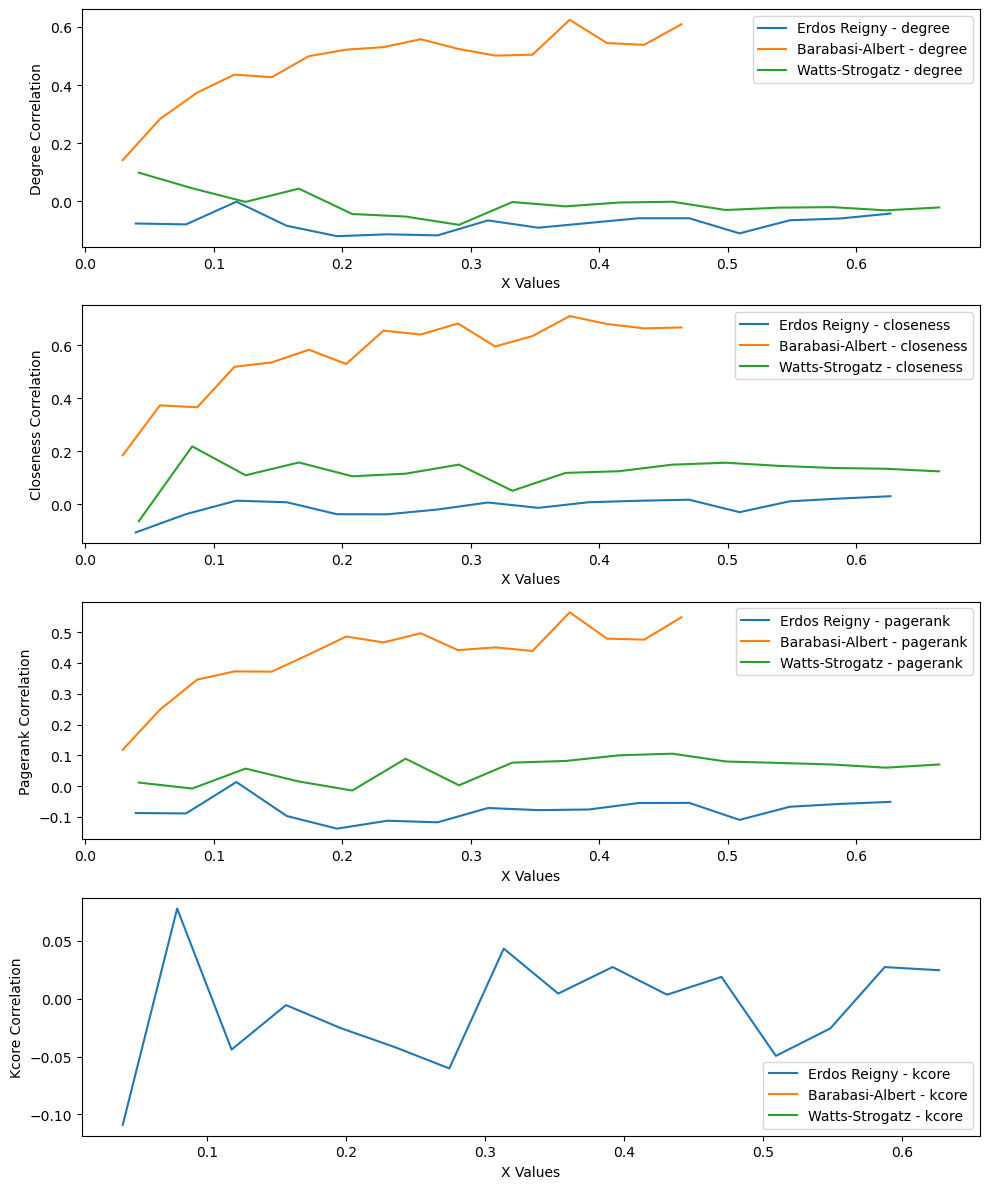

In [1137]:
plot_correlations(nets)

## T3 Produce the scatter plot of centrality measure vs spreading ability.
Do a scatter plot ofQivs.each centrality measurexi from the previous task, at the critical point λ=λCby normalizing the maximum value to one asQ/max(Q)andx/max(x), respectively. Graphs to consider:•Erdos-Renyi withN= 100nodes andp= 6/N.•Barabasi-Albert withN= 100nodes andm= 3.•Watts-Strogatz withN= 100nodes, rewiring probabilitypr= 0.02and coordination numberk= 6.


In [1138]:
def adapted_simulate_SIR(G, beta, gamma, time_steps, sample_size):
    nodes = list(G.nodes())
    results = {}

    for node in nodes:
        aggregated_values = []

        for _ in range(sample_size):
            set_infected = {node}
            set_susceptible = set(G) - set_infected
            set_recovered = set()

            node_neighbors = {n: set(G.neighbors(n)) for n in G}

            for _ in range(time_steps):
                newly_infected = set()
                newly_recovered = set()

                for infected_node in set_infected:
                    neighbors = node_neighbors[infected_node]
                    for neighbor in neighbors:
                        if neighbor in set_infected or neighbor in newly_infected:
                            continue
                        if np.random.rand() < beta:
                            newly_infected.add(neighbor)
                    if np.random.rand() < gamma:
                        newly_recovered.add(infected_node)

                set_susceptible -= newly_infected
                set_infected |= newly_infected
                set_infected -= newly_recovered
                set_recovered |= newly_recovered

            aggregated_values.append(len(set_recovered) / G.number_of_nodes())

        results[f"starting_node_{node}"] = np.mean(aggregated_values)

    return results

In [1139]:
def calculate_network_centrality_measures(graph):
    degree_centrality = nx.degree_centrality(graph)
    closeness_centrality = nx.closeness_centrality(graph)
    pagerank_scores = nx.pagerank(graph)
    k_core_numbers = nx.core_number(graph)

    return degree_centrality, closeness_centrality, pagerank_scores, k_core_numbers

In [1140]:
def normalize_centrality_values(centrality_dict):
    values_array = np.array(list(centrality_dict.values()))
    return values_array / values_array.max()


In [1141]:
def plot_normalized_centrality_vs_spreading_ability(spreading_ability, degree, closeness, pagerank, k_core, graph_title):
    plt.scatter(x=spreading_ability, y=degree, label='Degree Centrality', alpha=0.2)
    plt.scatter(x=spreading_ability, y=closeness, label='Closeness Centrality', alpha=0.2)
    plt.scatter(x=spreading_ability, y=pagerank, label='PageRank Centrality', alpha=0.2)
    plt.scatter(x=spreading_ability, y=k_core, label='K-Core Centrality', alpha=0.2)
    plt.xlabel('$Q_{i}$ (Normalized Spreading Ability)', fontsize=15)
    plt.ylabel('Normalized Centrality Measure', fontsize=13)
    plt.title(graph_title)
    plt.legend()
    plt.show()

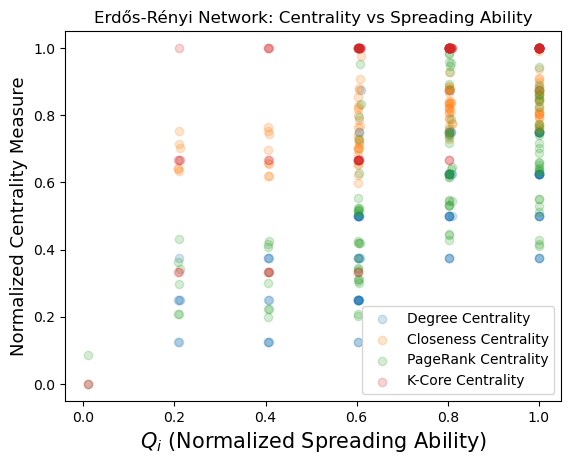

In [1142]:
erdos_renyi_graph = nx.erdos_renyi_graph(n=100, p=0.05)
degree_cent, closeness_cent, pagerank_cent, k_core_cent = calculate_network_centrality_measures(erdos_renyi_graph)

# Computing and normalizing spreading ability
spreading_ability_results = adapted_simulate_SIR(erdos_renyi_graph, beta=0.1, gamma=0.1, time_steps=500, sample_size=5)
normalized_spreading_ability = normalize_centrality_values(spreading_ability_results)

# Normalizing centrality measures
normalized_degree_cent = normalize_centrality_values(degree_cent)
normalized_closeness_cent = normalize_centrality_values(closeness_cent)
normalized_pagerank_cent = normalize_centrality_values(pagerank_cent)
normalized_k_core_cent = normalize_centrality_values(k_core_cent)

# Plotting
plot_normalized_centrality_vs_spreading_ability(normalized_spreading_ability, normalized_degree_cent, normalized_closeness_cent, normalized_pagerank_cent, normalized_k_core_cent, 'Erdős-Rényi Network: Centrality vs Spreading Ability')

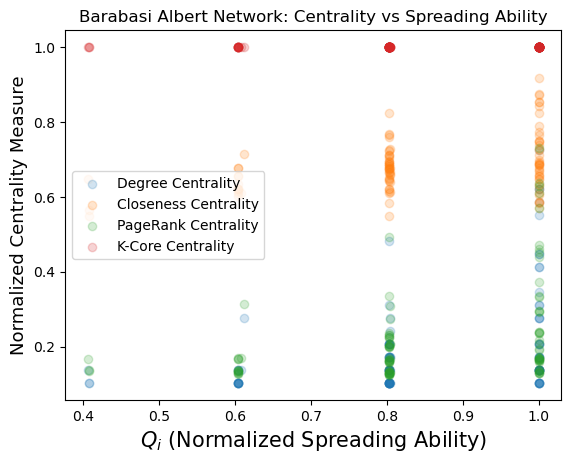

In [1143]:
barabasi_albert_graph = nx.barabasi_albert_graph(n=100, m=3)
degree_cent, closeness_cent, pagerank_cent, k_core_cent = calculate_network_centrality_measures(barabasi_albert_graph)

# Computing and normalizing spreading ability
spreading_ability_results = adapted_simulate_SIR(barabasi_albert_graph, beta=0.1, gamma=0.1, time_steps=500, sample_size=5)
normalized_spreading_ability = normalize_centrality_values(spreading_ability_results)

# Normalizing centrality measures
normalized_degree_cent = normalize_centrality_values(degree_cent)
normalized_closeness_cent = normalize_centrality_values(closeness_cent)
normalized_pagerank_cent = normalize_centrality_values(pagerank_cent)
normalized_k_core_cent = normalize_centrality_values(k_core_cent)

# Plotting
plot_normalized_centrality_vs_spreading_ability(normalized_spreading_ability, normalized_degree_cent, normalized_closeness_cent, normalized_pagerank_cent, normalized_k_core_cent, 'Barabasi Albert Network: Centrality vs Spreading Ability')

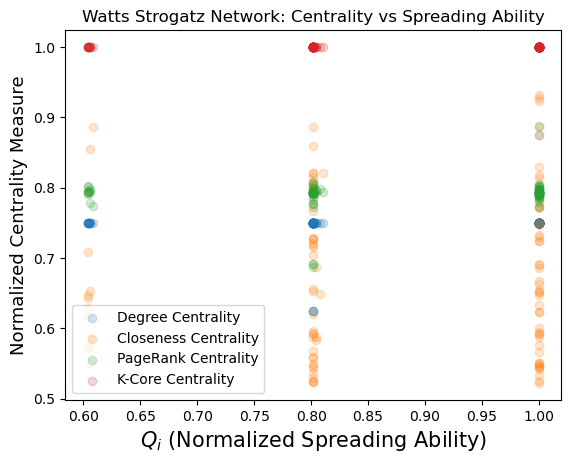

In [1144]:
watts_strogatz_graph = nx.watts_strogatz_graph(n=100, k=6, p=0.02)
degree_cent, closeness_cent, pagerank_cent, k_core_cent = calculate_network_centrality_measures(watts_strogatz_graph)

# Computing and normalizing spreading ability
spreading_ability_results = adapted_simulate_SIR(watts_strogatz_graph, beta=0.1, gamma=0.1, time_steps=500, sample_size=5)
normalized_spreading_ability = normalize_centrality_values(spreading_ability_results)

# Normalizing centrality measures
normalized_degree_cent = normalize_centrality_values(degree_cent)
normalized_closeness_cent = normalize_centrality_values(closeness_cent)
normalized_pagerank_cent = normalize_centrality_values(pagerank_cent)
normalized_k_core_cent = normalize_centrality_values(k_core_cent)

# Plotting
plot_normalized_centrality_vs_spreading_ability(normalized_spreading_ability, normalized_degree_cent, normalized_closeness_cent, normalized_pagerank_cent, normalized_k_core_cent, 'Watts Strogatz Network: Centrality vs Spreading Ability')

## T4


In [1145]:
graphs

{'graph_jazz_collab': <networkx.classes.graph.Graph at 0x1339dfb90>,
 'graph1.2': <networkx.classes.graph.Graph at 0x12da74990>,
 'graph1.1': <networkx.classes.graph.Graph at 0x12db0fcd0>,
 'graph_madrid': <networkx.classes.graph.Graph at 0x1339f2410>}

In [1146]:
madrid_graph = nx.read_gml('./datasets/graph_madrid.gml')
jazz_collab_graph = nx.read_gml('./datasets/graph_jazz_collab.gml')

print("Madrid graph is a", type(madrid_graph))
print("Node labels in Madrid graph:", list(madrid_graph.nodes(data=True))[0:5])

print("Jazz Collaboration graph is a", type(jazz_collab_graph))
print("Node labels in Jazz Collaboration graph:", list(jazz_collab_graph.nodes(data=True))[0:5])
# Conversion
madrid_graph = madrid_graph.to_undirected() if not isinstance(madrid_graph, nx.Graph) else madrid_graph
jazz_collab_graph = jazz_collab_graph.to_undirected() if not isinstance(jazz_collab_graph, nx.Graph) else jazz_collab_graph

Madrid graph is a <class 'networkx.classes.graph.Graph'>
Node labels in Madrid graph: [('1', {}), ('2', {}), ('3', {}), ('4', {}), ('5', {})]
Jazz Collaboration graph is a <class 'networkx.classes.graph.Graph'>
Node labels in Jazz Collaboration graph: [('0', {}), ('1', {}), ('2', {}), ('3', {}), ('4', {})]


In [1147]:
# Ensure the graphs are undirected, as SIR simulation typically runs on undirected graphs
madrid_graph = graphs['graph_madrid'].to_undirected()
jazz_collab_graph = graphs['graph_jazz_collab'].to_undirected()

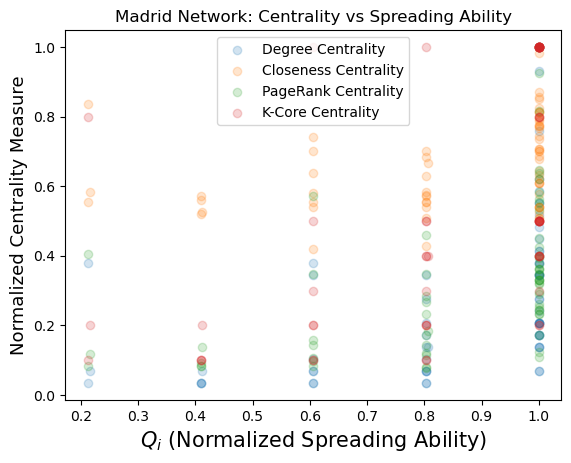

In [1148]:
# Perform the analysis on the Madrid graph
madrid_spreading_ability = adapted_simulate_SIR(madrid_graph, beta=0.1, gamma=0.1, time_steps=500, sample_size=5)
madrid_degree, madrid_closeness, madrid_pagerank, madrid_kcore = calculate_network_centrality_measures(madrid_graph)

# Normalize the centrality values
madrid_degree_norm = normalize_centrality_values(madrid_degree)
madrid_closeness_norm = normalize_centrality_values(madrid_closeness)
madrid_pagerank_norm = normalize_centrality_values(madrid_pagerank)
madrid_kcore_norm = normalize_centrality_values(madrid_kcore)

# Plotting the results for the Madrid graph
plot_normalized_centrality_vs_spreading_ability(
    normalize_centrality_values(madrid_spreading_ability),
    madrid_degree_norm,
    madrid_closeness_norm,
    madrid_pagerank_norm,
    madrid_kcore_norm,
    'Madrid Network: Centrality vs Spreading Ability'
)

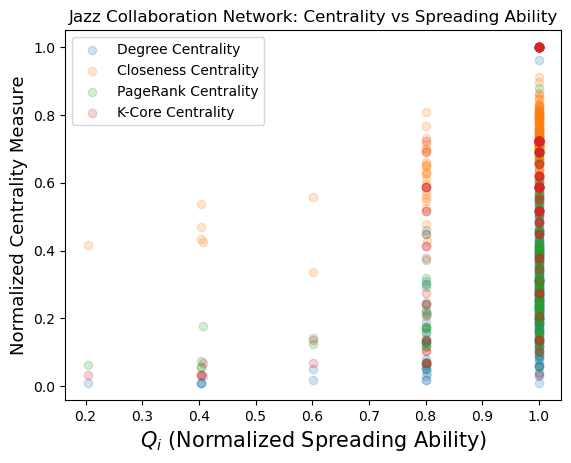

In [1149]:
# Perform the analysis on the Jazz Collaboration graph
jazz_spreading_ability = adapted_simulate_SIR(jazz_collab_graph, beta=0.1, gamma=0.1, time_steps=500, sample_size=5)
jazz_degree, jazz_closeness, jazz_pagerank, jazz_kcore = calculate_network_centrality_measures(jazz_collab_graph)

# Normalize the centrality values
jazz_degree_norm = normalize_centrality_values(jazz_degree)
jazz_closeness_norm = normalize_centrality_values(jazz_closeness)
jazz_pagerank_norm = normalize_centrality_values(jazz_pagerank)
jazz_kcore_norm = normalize_centrality_values(jazz_kcore)

# Plotting the results for the Jazz Collaboration graph
plot_normalized_centrality_vs_spreading_ability(
    normalize_centrality_values(jazz_spreading_ability),
    jazz_degree_norm,
    jazz_closeness_norm,
    jazz_pagerank_norm,
    jazz_kcore_norm,
    'Jazz Collaboration Network: Centrality vs Spreading Ability'
)

Overall:
- Examine if centrality correlates with spreading ability -> more central individuals might also be those who can spread influence more effectively.
- Consider the structural differences between the networks that may affect the patterns observed.
Madrid Network:
- Centrality and Influenced: High centrality can probably indicate key figures in the network (hubs), which potentially involved in opefrational roles or information dissemination within the group.
- Spreading Ability: Important for understanding the network's resilience and identifying critical nodes.
Jazz Collaboration Network
- Centrality and Influence: Centrality could reflect musicians' prominence or their role as connectors in the jazz community.
- Spreading Ability: May represent a musician's capacity to spread and influence new musical styles or songs through collabordations.
